In [1]:
#Import
import pandas as p
import matplotlib.pyplot as plt
import collections as col
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
from sentence_transformers import SentenceTransformer
import seaborn as sns
import umap
from collections import defaultdict
from gensim.models import Word2Vec
import re
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
import nltk
from sklearn.feature_extraction import text
from langdetect import detect


C:\Users\chass\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Initialisation des variables et extraction des donnees

csvF = p.read_csv("./train.csv");
context = csvF["Context"]
response = csvF["Response"]


In [3]:
#nettoyage des données

context = context.str.lower()
response= response.str.lower()

context  = context.str.replace('\'', "")
response  = response.str.replace('\'', "")

context = context.drop_duplicates();
response = response.drop_duplicates();
response = response.dropna();

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

response = response.dropna()
response = response.astype(str)

response = response[
    response.apply(is_english)
]

print(context)
print(response)

0       im going through some things with my feelings ...
23      i have so many issues to address. i have a his...
70      i have been feeling more and more down for ove...
72      i’m facing severe depression and anxiety and i...
81      how can i get to a place where i can be conten...
                              ...                        
3446    what am i doing wrong? my wife and i are fight...
3491    we rent from from my boyfriends parents. his f...
3501    my mother is combative with me when i say i do...
3509    the birth mother attempted suicide several tim...
3510    i think adult life is making him depressed and...
Name: Context, Length: 995, dtype: str
0       if everyone thinks youre worthless, then maybe...
1       hello, and thank you for your question and see...
2       first thing id suggest is getting the sleep yo...
3       therapy is essential for those that are feelin...
4       i first want to let you know that you are not ...
                              ...

In [4]:
#Trouver le nombre de patient
print(len(context))

995


In [5]:
#Trouver le nombre de therapeute anglais
print(len(response))

2425


In [22]:
#Nombre de conversation par therapeute en moyenne

conversationTherapeute = csvF
conversationTherapeute = conversationTherapeute.drop_duplicates()
conversationTherapeute = conversationTherapeute.groupby(["Response"]).count()
moyenneT = conversationTherapeute.Context.mean()
print(moyenneT)

1.1088628085795225


In [7]:
#Nombre d'echange moyen par conversation
conversation = csvF
conversation = conversation.drop_duplicates()
conversation = conversation.groupby(["Context"]).count()
moyenne = conversation.Response.mean()
print(moyenne)

2.7537688442211055


In [8]:
#Frequence mot dans les patients

contextDictionnaire = p.DataFrame(context)
contextDictionnaire = contextDictionnaire.drop_duplicates()
listeIndex =contextDictionnaire.index

#etape 1 : fusionner toutes les cellules de la table dans une seule ou faire une colonne avec un mot par case

contextSplit = contextDictionnaire["Context"].str.split(" ")
listeSplit = []

for i in range (len(contextSplit) ):
    if i in listeIndex :
        listeSplit = listeSplit + contextSplit[i]

#etape 2 : recuperer le nombre total de mot

print (len(listeSplit))

#etape 3 : group by mot, avec le compte d'apparition du mot

compte = col.Counter(listeSplit)
print(compte.values())
print(compte.keys())

compteSorted = compte.most_common()
print(compteSorted)

#etape 4 : colonne frequence avec la frequence d'apparition de chaque mot
listeFrequence = []
for i in range (len(compteSorted) - 1) :
    listeFrequence.append((compteSorted[i][0], compteSorted[i][1], compteSorted[i][1]/len(listeSplit)))

print(listeFrequence)

23610
dict_values([236, 42, 23, 27, 38, 258, 630, 11, 871, 25, 1680, 3, 11, 131, 18, 202, 58, 111, 101, 5, 5, 111, 1, 177, 78, 64, 15, 100, 1, 2, 55, 21, 750, 6, 5, 101, 24, 4, 90, 6, 22, 280, 39, 1, 292, 93, 12, 10, 1, 505, 2, 8, 1, 46, 1, 1, 2, 126, 1, 1, 9, 32, 1, 14, 5, 8, 2, 15, 120, 2, 11, 204, 14, 1, 1, 73, 4, 26, 9, 18, 2, 242, 1, 30, 13, 41, 4, 20, 39, 9, 9, 7, 15, 2, 84, 63, 1, 38, 22, 203, 108, 4, 2, 9, 38, 107, 199, 144, 11, 125, 54, 1, 276, 67, 10, 11, 387, 2, 99, 5, 1, 4, 8, 18, 2, 67, 17, 1, 22, 2, 5, 6, 12, 2, 1, 50, 6, 4, 8, 1, 1, 6, 8, 1, 7, 11, 156, 81, 5, 23, 5, 1, 1, 1, 10, 12, 2, 3, 91, 28, 12, 2, 18, 16, 35, 11, 149, 13, 38, 10, 89, 70, 5, 8, 17, 1, 51, 8, 2, 15, 7, 1, 206, 6, 5, 1, 47, 1, 1, 1, 2, 2, 3, 1, 1, 14, 2, 17, 5, 50, 1, 99, 1, 1, 19, 8, 16, 4, 6, 2, 72, 7, 7, 1, 4, 1, 3, 7, 1, 4, 1, 36, 1, 4, 1, 1, 1, 1, 1, 128, 20, 31, 1, 1, 1, 19, 1, 41, 15, 1, 1, 1, 9, 3, 27, 2, 1, 1, 42, 6, 5, 1, 1, 6, 7, 2, 2, 22, 18, 1, 115, 130, 1, 10, 16, 1, 260, 3, 1, 1, 2, 63

In [9]:
#Frequence mot pour tout les therapeutes

responseDictionnaire = p.DataFrame(response)
responseDictionnaire = responseDictionnaire.drop_duplicates()
listeIndex =responseDictionnaire.index

#etape 1 : fusionner toutes les cellules de la table dans une seule ou faire une colonne avec un mot par case

responseSplit = responseDictionnaire["Response"].str.split(" ")
listeSplitR = []

for i in range (len(responseSplit) ):
    if i in listeIndex :
        if isinstance(responseSplit[i],list) :
            listeSplitR = listeSplitR + responseSplit[i]

#etape 2 : recuperer le nombre total de mot

print (len(listeSplitR))

#etape 3 : group by mot, avec le compte d'apparition du mot

compteR = col.Counter(listeSplitR)
print(compteR.values())
print(compteR.keys())

compteSortedR = compteR.most_common()
print(compteSortedR)

#etape 4 : colonne frequence avec la frequence d'apparition de chaque mot
listeFrequenceR = []
for i in range (len(compteSortedR) - 1) :
    listeFrequenceR.append((compteSortedR[i][0], compteSortedR[i][1], compteSortedR[i][1]/len(listeSplitR)))

print(listeFrequenceR)

351266
dict_values([2365, 86, 20, 585, 10, 759, 238, 14059, 632, 14630, 634, 311, 902, 18, 880, 1, 9486, 115, 24, 4834, 555, 7943, 505, 51, 6689, 78, 24, 1, 3031, 358, 2, 9287, 212, 312, 256, 2252, 179, 209, 4, 3743, 1, 167, 1, 4381, 518, 2, 35, 2, 11, 66, 1157, 6500, 81, 61, 6399, 419, 624, 746, 24, 777, 4, 116, 512, 12, 900, 2, 3837, 17, 622, 269, 1474, 2038, 96, 2666, 17, 1, 444, 264, 9, 21, 30, 11, 87, 1147, 88, 192, 1386, 303, 1170, 39, 472, 1, 1, 219, 7170, 592, 7, 1602, 210, 5, 316, 263, 5, 46, 70, 3459, 192, 59, 42, 1833, 91, 22, 14, 30, 374, 65, 48, 2587, 97, 22, 916, 128, 152, 1, 1223, 39, 316, 316, 726, 180, 56, 6, 21, 13, 301, 110, 209, 811, 409, 1157, 461, 29, 217, 1, 489, 5, 41, 26, 42, 4, 410, 43, 36, 57, 637, 48, 482, 405, 179, 63, 53, 317, 396, 124, 152, 52, 1, 2689, 115, 113, 1338, 1, 2, 722, 4, 1, 337, 5, 62, 1167, 116, 82, 1162, 44, 135, 266, 85, 115, 95, 255, 27, 631, 45, 54, 163, 120, 181, 128, 24, 110, 8, 35, 30, 357, 51, 1, 125, 51, 12, 27, 177, 33, 2387, 4, 581

In [10]:
#Dictionnaire de mot (avec la frequence pour chaque mot) (sans retrait de ligne)
dictionnaireFusion = compte | compteR
dictionnaireSorted = dictionnaireFusion.most_common()
totalMot = len(listeSplit) + len(listeSplitR)
print(totalMot)
print (dictionnaireSorted)
listeFrequenceF = []
for i in range (len(dictionnaireSorted) - 1) :
    listeFrequenceF.append((dictionnaireSorted[i][0], dictionnaireSorted[i][1], dictionnaireSorted[i][1]/totalMot))

print(listeFrequenceF)

374876
[('to', 14630), ('you', 14059), ('the', 9486), ('and', 9287), ('a', 7943), ('your', 7170), ('is', 6689), ('of', 6500), ('that', 6399), ('in', 4834), ('are', 4381), ('with', 3837), ('be', 3743), ('for', 3459), ('it', 3342), ('can', 3031), ('or', 2689), ('this', 2666), ('have', 2587), ('i', 2387), ('if', 2365), ('what', 2330), ('not', 2252), ('as', 2117), ('about', 2038), ('on', 1833), ('may', 1602), ('will', 1523), ('feel', 1474), ('do', 1386), ('they', 1338), ('would', 1330), ('like', 1223), ('we', 1206), ('more', 1170), ('help', 1167), ('how', 1162), ('some', 1157), ('there', 1157), ('from', 1147), ('when', 1120), ('who', 1099), ('but', 1073), ('he', 1042), ('yourself', 937), ('at', 916), ('an', 913), ('people', 902), ('so', 900), ('out', 880), ('know', 856), ('time', 820), ('other', 817), ('want', 816), ('one', 811), ('by', 803), ('their', 777), ('get', 772), ('her', 767), ('being', 759), ('then', 759), ('relationship', 751), ('good', 746), ('therapist', 737), ('its', 726), ('

In [11]:
#Identification sujet majeurs : lexique de mon choix
donneeLexique = p.DataFrame(context)
donneeLexique = donneeLexique.drop_duplicates()

lexiqueD = ["depress", "sad", "suicide", "worthless", "anxie", "bothering","diminish", "dissapoint"]
lexiqueJ = ["joy", "happy", "glad", "delight", "pleasure", "relief", "entertainment"]

listeD = []
listeJ = []

for i in range (len(lexiqueD)):
    listeD.append(donneeLexique[donneeLexique['Context'].str.contains(lexiqueD[i])])
compteD = len(listeD)

listeDFinal = []
for i in range (len(listeD)) :
    ligne = listeD[i]["Context"].tolist()
    for j in range (len(ligne)) :
        if ligne[j] not in listeDFinal :
            listeDFinal.append(ligne[j])

print (len(listeDFinal))

for i in range (len(lexiqueJ)):
    listeJ.append(donneeLexique[donneeLexique['Context'].str.contains(lexiqueJ[i])])
compteJ = len(listeJ)

listeJFinal = []
for i in range (len(listeJ)) :
    ligne = listeJ[i]["Context"].tolist()
    for j in range (len(ligne)) :
        
        if ligne[j] not in listeJFinal :
            listeJFinal.append(ligne[j])

print (len(listeJFinal))


197
86


In [12]:
#Fonction de clustering par des vecteur tf-idf
def vecteurTfIdf (df):

    tfidf = TfidfVectorizer(stop_words='english')

    vec = tfidf.fit_transform(df.to_list())

    kmeans = KMeans(n_clusters=3)
    ymeans = kmeans.fit_predict(vec)

    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(vec.toarray())

    plt.figure()
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=ymeans)

    plt.show()

    df = p.DataFrame({
        "text": df.reset_index(drop=True),
        "cluster": ymeans
    })

    feature_names = tfidf.get_feature_names_out()

    for i in range(kmeans.n_clusters) :
        indice = np.where(ymeans==i)
        mean_tfidf = vec[indice].mean(axis=0)
        mean_tfidf = np.asarray(mean_tfidf).flatten()

        top_indices = mean_tfidf.argsort()[::-1][:20]
        top_words = [feature_names[j] for j in top_indices]

        print("\nCluster ", i, " :")
        print(top_words)

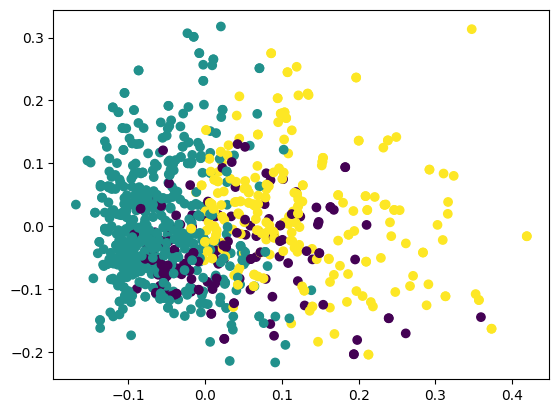


Cluster  0  :
['im', 'like', 'feel', 'just', 'ive', 'depressed', 'feeling', 'going', 'talk', 'need', 'job', 'dad', 'want', 'time', 'really', 'help', 'know', 'away', 'friends', 'people']

Cluster  1  :
['years', 'time', 'feel', 'like', 'just', 'love', 'help', 'told', 'boyfriend', 'relationship', 'says', 'ive', 'child', 'family', 'things', 'really', 'sex', 'husband', 'said', 'got']

Cluster  2  :
['dont', 'know', 'feel', 'want', 'like', 'im', 'just', 'really', 'relationship', 'people', 'ive', 'time', 'stop', 'boyfriend', 'say', 'love', 'think', 'life', 'talk', 'wrong']


In [13]:
#Identification sujet majeurs : cluster de mot pour les patients
vecteurTfIdf(context)

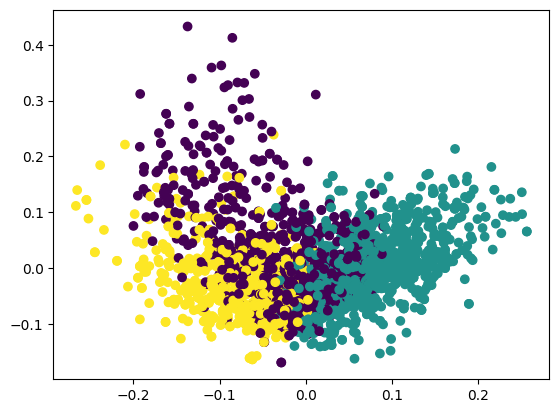


Cluster  0  :
['feel', 'therapist', 'people', 'therapy', 'like', 'time', 'life', 'thoughts', 'help', 'feelings', 'feeling', 'good', 'way', 'things', 'emotions', 'know', 'work', 'try', 'want', 'counselor']

Cluster  1  :
['relationship', 'feel', 'want', 'know', 'like', 'partner', 'love', 'dont', 'time', 'youre', 'person', 'way', 'need', 'make', 'trust', 'good', 'help', 'boyfriend', 'child', 'change']

Cluster  2  :
['anxiety', 'help', 'depression', 'counseling', 'issues', 'symptoms', 'trauma', 'therapist', 'therapy', 'work', 'self', 'support', 'helpful', 'counselor', 'health', 'like', 'treatment', 'life', 'able', 'professional']


In [14]:
#Identification sujet majeurs : cluster de mot pour les thérapeutes
vecteurTfIdf(response)

In [29]:
#Identification sujet majeurs : word embedding 

def get_top_words_per_cluster(words, embeddings, clusters, centroids, top_n=20):
    for cluster_id in range(len(centroids)):

        idx = np.where(clusters == cluster_id)[0]

        cluster_embeddings = embeddings[idx]
        centroid = centroids[cluster_id]

        distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)

        sorted_idx = np.argsort(distances)

        top_idx = idx[sorted_idx[:top_n]]

        liste_top = []
        for i in top_idx:
            liste_top.append(words[i])
        
        print("Cluster : ", cluster_id ,liste_top)

def embeddingMethod (df) :

    modele = SentenceTransformer("all-MiniLM-L6-v2")

    text = df.astype(str).tolist()

    embeddings = modele.encode(text, show_progress_bar=True)

    tokenized_sentences = [s.split() for s in df]
    model = Word2Vec(tokenized_sentences, vector_size=100, window=5, min_count=1)

    word_vectors = np.array([model.wv[w] for w in model.wv.index_to_key])
    words = model.wv.index_to_key

    k = 6
    kmeans = KMeans(n_clusters=k, random_state=42)

    word_clusters = kmeans.fit_predict(word_vectors)

    centroids = kmeans.cluster_centers_

    reducer = umap.UMAP(n_neighbors=15, n_components=2, random_state=42)
    word_vectors_2d = reducer.fit_transform(word_vectors)

    get_top_words_per_cluster(
        words,
        word_vectors,
        word_clusters,
        centroids,
        top_n=20
    )

In [30]:
embeddingMethod(context)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7874.26it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:05<00:00,  5.51it/s]
C:\Users\chass\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Cluster :  0 ['danger', 'ticked', 'license', 'extensive', 'symptoms.', 'ungrateful,', 'instructor', 'nasty', 'trauma.', 'nuts.', 'junk', 'going.', 'share', 'canada', 'skill', 'silent', 'self-harming.', 'roads.', 'resemble', 'questioning']
Cluster :  1 ['still', 'will', 'think', 'back', 'being', 'things', 'it.', 'would', 'time', 'years', 'also', 'there', 'told', 'should', 'help', 'more', 'got', 'two', 'one', 'i’m']
Cluster :  2 ['back.', 'lot.', 'havent', 'completely', 'school.', 'personality', 'new', 'abusive', 'point', 'look', 'panic', 'to.', 'problems', 'ago,', 'diagnosed', 'too.', 'away.', 'control', 'son', 'give']
Cluster :  3 ['fault,', 'honestly', 'memories', 'died.', 'conversations', 'running', 'world', 'true', 'later', 'face.', 'mom.', 'emotions.', 'ignore', 'texts', 'mentally', 'claims', 'husband’s', 'basically', 'cried', 'though,']
Cluster :  4 ['when', 'that', 'at', 'from', 'an', 'about', 'are', 'have', 'am', 'not', 'with', 'no', 'our', 'it', 'was', 'has', 'her', 'had', 'up'

In [31]:
#Identification sujet majeurs : word embedding pour les thérapeutes

embeddingMethod(response)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7578.52it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 76/76 [00:33<00:00,  2.24it/s]
C:\Users\chass\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Cluster :  0 ['byrunning', 'visite', 'lit', 'notions', 'depps', 'risk,', 'housework,', 'out.shame', 'activation', 'negativamente,', 'life.you', '-based', 'check,', 'teleterapia.', 'performs', 'work-related,', 'wrong.if', 'dead.', 'therapists!', 'memory."so']
Cluster :  1 ['either', 'specific', 'making', 'thought', 'practice', 'loving', 'simply', 'using', 'address', 'anger', 'every', 'away', 'behavior', 'small', 'avoid', 'down', 'off', 'once', 'enough', '(or']
Cluster :  2 ['seek', 'consider', 'both', 'support', 'counseling', 'hope', 'professional', 'should', 'also', 'helpful', 'through', 'work', 'give', 'wish', 'encourage', 'find', 'time', 'best', 'suggest', 'get']
Cluster :  3 ['and,', 'needed', 'along', 'confidence', 'reasonable', 'steps', 'protect', 'face', 'legal', 'action', 'happiness', 'minutes', '"what', 'w', 'appropriate', 'god', 'whole', 'age', 'break', 'day,']
Cluster :  4 ['warm', 'college', 'separation', 'expectations,', 'throwing', 'you"', 'whose', 'connection,', '(www.mar

In [32]:
#Identification sujet majeurs : modele d'extraction de sujet LDA pour les patients

def ldaMethod (df) :
    nltk.download('stopwords')

    stop_words = set(stopwords.words("english"))

    tokenized_sentences = [
        [
            w for w in re.findall(r"\b\w+\b", s.lower())
            if w not in stop_words
        ]
        for s in df
    ]

    dictionary = corpora.Dictionary(tokenized_sentences)

    dictionary.filter_extremes(no_below=2, no_above=0.5)

    corpus = [dictionary.doc2bow(text) for text in tokenized_sentences]

    k = 5

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=10,
        random_state=42
    )

    for i in range(k):
        print ("topic ", i)
        a = lda_model.show_topic(i, topn=20)
        listeTopic = []
        for element in a :
            listeTopic.append(element[0])
        print(listeTopic)

In [19]:
#Identification sujet majeurs : modele d'extraction de sujet LDA pour les patients
ldaMethod(context)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


topic  0
['im', 'feel', 'like', 'dont', 'want', 'know', 'years', 'get', 'time', 'ive', 'relationship', 'really', 'always', 'never', 'boyfriend', 'love', 'help', 'life', 'people', 'back']
topic  1
['im', 'get', 'know', 'dont', 'time', 'even', 'think', 'told', 'cant', 'would', 'one', 'like', 'want', 'every', 'family', 'boyfriend', 'got', 'friends', 'help', 'things']


In [20]:
#Identification sujet majeurs : modele d'extraction de sujet LDA pour les thérapeutes
ldaMethod(response)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


topic  0
['feel', 'may', 'like', 'relationship', 'want', 'would', 'time', 'people', 'things', 'know', 'one', 'help', 'get', 'dont', 'person', 'good', 'way', 'need', 'make', 'something']
topic  1
['help', 'may', 'therapist', 'would', 'feel', 'anxiety', 'also', 'therapy', 'way', 'thoughts', 'like', 'people', 'relationship', 'feeling', 'time', 'good', 'many', 'self', 'get', 'life']
